In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)   # Display all columns in backend and they cannot be show data in the frontend
pd.set_option('display.max_rows', None)      # Display all rows 

In [19]:
# apni file ka path daalen
df = pd.read_csv('yellow_tripdata_2015-01.csv', nrows=500000)  
# agar CSV hai to: df = pd.read_csv('file.csv')

print(df.shape)   # kitni rows, kitne columns hain
df.head()          # pehli 5 rows dekhen
df.info()          # data types aur missing values ka andaza

(500000, 19)
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               500000 non-null  int64  
 1   tpep_pickup_datetime   500000 non-null  str    
 2   tpep_dropoff_datetime  500000 non-null  str    
 3   passenger_count        500000 non-null  int64  
 4   trip_distance          500000 non-null  float64
 5   pickup_longitude       500000 non-null  float64
 6   pickup_latitude        500000 non-null  float64
 7   RateCodeID             500000 non-null  int64  
 8   store_and_fwd_flag     500000 non-null  str    
 9   dropoff_longitude      500000 non-null  float64
 10  dropoff_latitude       500000 non-null  float64
 11  payment_type           500000 non-null  int64  
 12  fare_amount            500000 non-null  float64
 13  extra                  500000 non-null  float64
 14  mta_tax                500000 non-

In [20]:
df.info()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               500000 non-null  int64  
 1   tpep_pickup_datetime   500000 non-null  str    
 2   tpep_dropoff_datetime  500000 non-null  str    
 3   passenger_count        500000 non-null  int64  
 4   trip_distance          500000 non-null  float64
 5   pickup_longitude       500000 non-null  float64
 6   pickup_latitude        500000 non-null  float64
 7   RateCodeID             500000 non-null  int64  
 8   store_and_fwd_flag     500000 non-null  str    
 9   dropoff_longitude      500000 non-null  float64
 10  dropoff_latitude       500000 non-null  float64
 11  payment_type           500000 non-null  int64  
 12  fare_amount            500000 non-null  float64
 13  extra                  500000 non-null  float64
 14  mta_tax                500000 non-null  float64

VendorID                   int64
tpep_pickup_datetime         str
tpep_dropoff_datetime        str
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RateCodeID                 int64
store_and_fwd_flag           str
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

In [21]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
print(missing_df[missing_df['missing_count'] > 0])

Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []


In [22]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 102


In [1]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

NameError: name 'pd' is not defined

In [24]:
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['trip_duration_minutes'].describe()

count    500000.000000
mean         13.102790
std          35.005077
min         -22.100000
25%           6.100000
50%           9.933333
75%          15.750000
max        1439.633333
Name: trip_duration_minutes, dtype: float64

In [25]:
print("Negative duration:", (df['trip_duration_minutes'] < 0).sum())
print("Zero duration:", (df['trip_duration_minutes'] == 0).sum())
print("Less than 1 minute:", (df['trip_duration_minutes'] < 1).sum())
print("More than 3 hours (180 min):", (df['trip_duration_minutes'] > 180).sum())

# Passenger count check
print(df['passenger_count'].value_counts(dropna=False))

# Trip distance check
print("Zero distance trips:", (df['trip_distance'] == 0).sum())
print("Negative distance:", (df['trip_distance'] < 0).sum())

# Fare amount check (sirf audit ke liye, model mein use nahi karna kyunke leakage hai)
print("Negative fare:", (df['fare_amount'] < 0).sum())

Negative duration: 6
Zero duration: 595
Less than 1 minute: 4134
More than 3 hours (180 min): 352
passenger_count
1    353289
2     70978
5     27218
3     20701
6     17720
4      9822
0       271
9         1
Name: count, dtype: int64
Zero distance trips: 3256
Negative distance: 0
Negative fare: 158


In [26]:
print("Unique pickup zones:", df['pickup_latitude'].nunique())
print("Unique dropoff zones:", df['dropoff_latitude'].nunique())

Unique pickup zones: 36115
Unique dropoff zones: 47136


In [27]:
# Filtering thresholds (aap explain karenge report mein ke ye kyun chune)
df_clean = df[
    (df['trip_duration_minutes'] >= 1) &        # 1 min se kam trip = ghalat
    (df['trip_duration_minutes'] <= 180) &       # 3 ghante se zyada = outlier
    (df['trip_distance'] > 0) &                  # 0 distance = invalid
    (df['passenger_count'] > 0)                  # 0 passenger = invalid
]

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Removed:", len(df) - len(df_clean))

Original rows: 500000
Clean rows: 494634
Removed: 5366


In [28]:
df_clean = df_clean.copy()  # warning avoid karne ke liye

df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour
df_clean['pickup_day'] = df_clean['tpep_pickup_datetime'].dt.day_name()
df_clean['pickup_month'] = df_clean['tpep_pickup_datetime'].dt.month

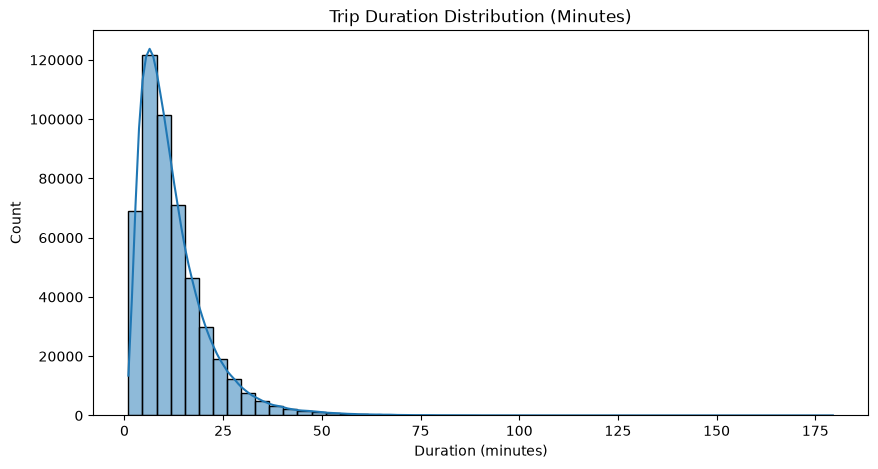

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean['trip_duration_minutes'], bins=50, kde=True)
plt.title('Trip Duration Distribution (Minutes)')
plt.xlabel('Duration (minutes)')
plt.show()

# Ye aapko dikhayega ke zyada tar trips kitni der ki hoti hain (shayad right-skewed hoga, matlab zyada trips short honge, kuch bohot lambi).

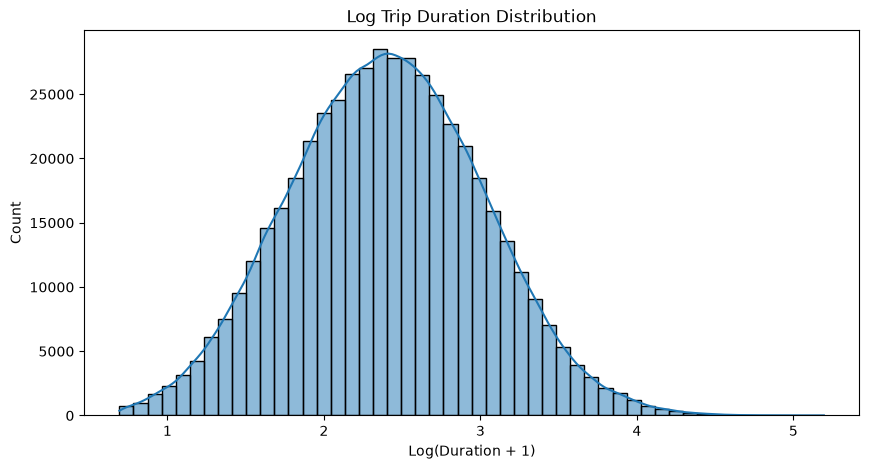

In [ ]:
df_clean['log_duration'] = np.log1p(df_clean['trip_duration_minutes'])

plt.figure(figsize=(10,5))
sns.histplot(df_clean['log_duration'], bins=50, kde=True)
plt.title('Log Trip Duration Distribution')
plt.xlabel('Log(Duration + 1)')
plt.show()

# yeh aapko dikhayega ke log transformation ke baad distribution zyada normal (bell-shaped) ho jata hai, jo regression models ke liye better hota hai.

# Farq dekhen dono graphs mein — pehla wala lamba tail wala hoga (skewed), doosra zyada bell-shape (normal) jaisa hoga.

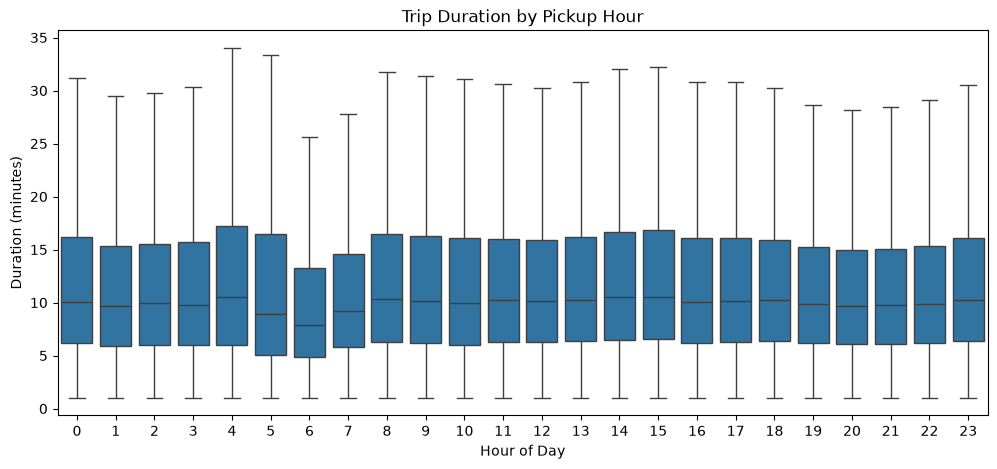

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x='pickup_hour', y='trip_duration_minutes', data=df_clean, showfliers=False)
plt.title('Trip Duration by Pickup Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Duration (minutes)')
plt.show()


# Ye aapko dikhayega ke din ke kis time par trips zyada lambi ya choti hoti hain.
# showfliers=False isliye lagaya taake outliers graph ko squeeze na karen — sirf normal range dikhega.

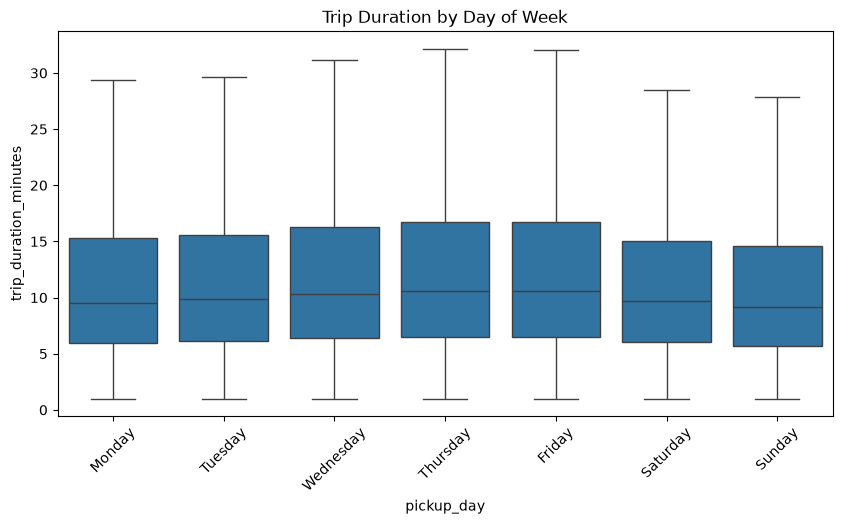

In [ ]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,5))
sns.boxplot(x='pickup_day', y='trip_duration_minutes', data=df_clean, order=order, showfliers=False)
plt.title('Trip Duration by Day of Week')
plt.xticks(rotation=45)
plt.show()

# Ye aapko dikhayega ke hafte ke kis din trips zyada lambi ya choti hoti hain.

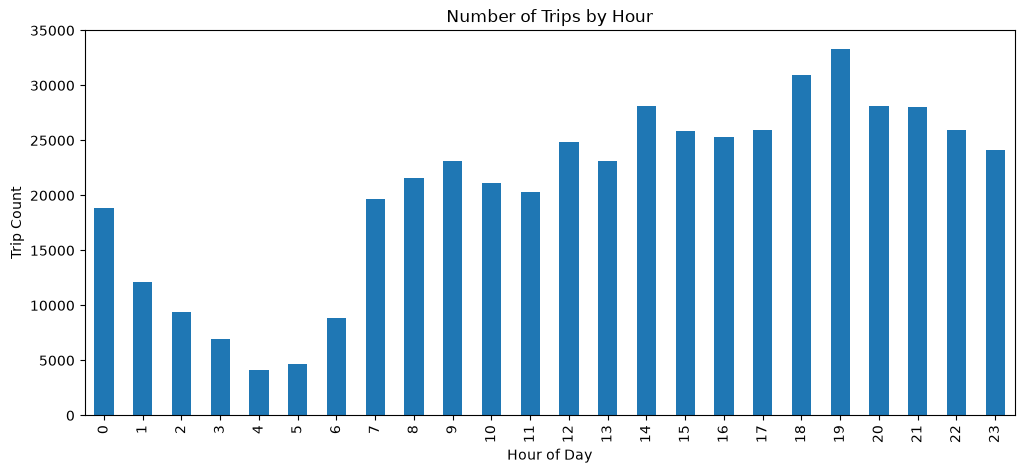

In [ ]:
plt.figure(figsize=(12,5))
df_clean['pickup_hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Trips by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Trip Count')
plt.show()

# Ye aapko dikhayega ke din ke kis time par zyada trips hoti hain.

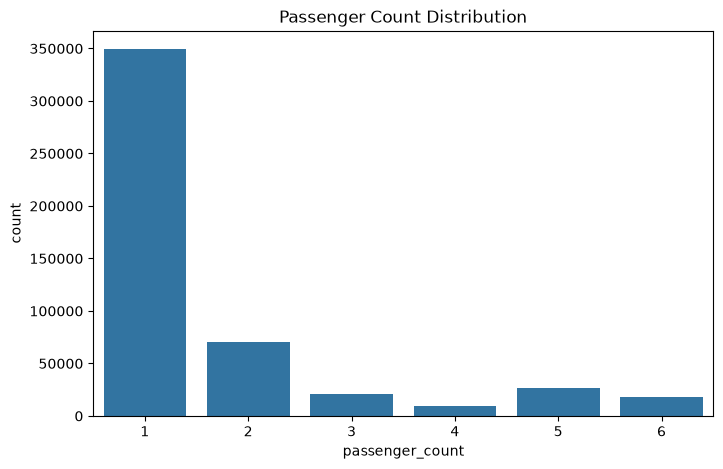

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='passenger_count', data=df_clean)
plt.title('Passenger Count Distribution')
plt.show()

# Ye aapko dikhayega ke zyada tar trips mein kitne passengers hote hain.

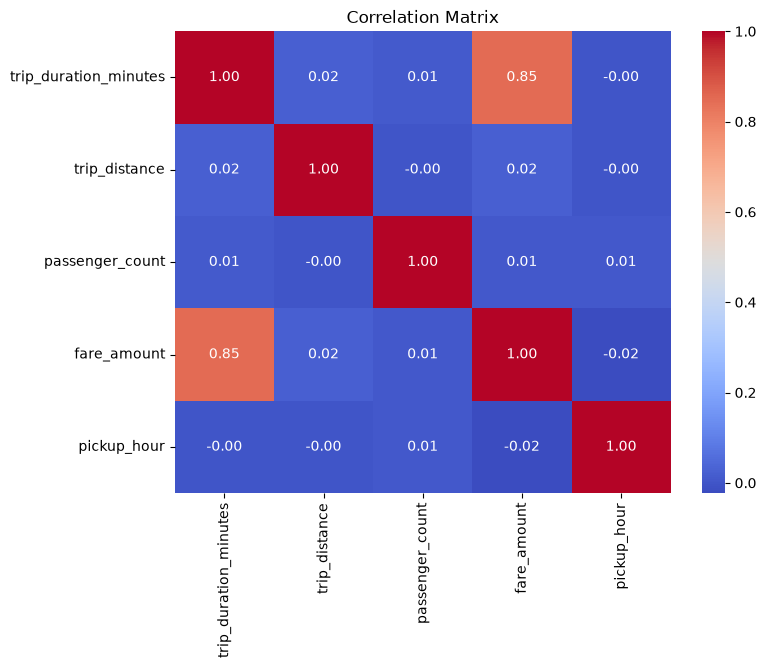

In [35]:
numeric_cols = ['trip_duration_minutes', 'trip_distance', 'passenger_count', 'fare_amount', 'pickup_hour']

plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Ye aapko dikhayega ke kaunse numeric features ek doosre se kitne correlated hain. High correlation wale features ko model mein carefully use karna chahiye, kyunki multicollinearity ka issue ho sakta hai.